In [1]:
from itertools import cycle, islice

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import scipy.misc
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn import cluster, datasets
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples
from sklearn.model_selection import KFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_88742/2600773363.py:9: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


## Presidential Speech Data

In [2]:
df = pd.read_csv('./presidential_speech.csv', index_col=0)
df.head()

,amount,appropri,british,cent,commerci,commission,consider,develop,expenditur,farm,...,nuclear,percent,program,spend,technolog,today,tonight,worker,inflat,soviet
Abraham Lincoln,3.433987,2.397895,1.791759,2.564949,2.708050,2.079442,3.555348,2.079442,2.944439,0.693147,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Andrew Jackson,4.248495,4.663439,2.995732,1.945910,3.828641,3.218876,4.700480,1.791759,3.951244,1.098612,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Andrew Johnson,4.025352,3.091042,2.833213,3.332205,2.772589,2.079442,3.637586,2.302585,3.912023,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Barack Obama,1.386294,0.000000,0.000000,1.386294,0.000000,0.000000,0.000000,3.178054,0.000000,1.098612,...,3.401197,3.526361,3.713572,3.784190,3.526361,4.248495,4.644391,4.189655,1.098612,1.386294
Benjamin Harrison,4.060443,4.174387,2.302585,4.304065,3.663562,3.465736,4.276666,3.555348,3.737670,2.944439,...,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
#helper functions
def plot_proj_clusters(ax, PCData, GroupData, title=""):
    """
    (Optional) Plots projected clusters with text labels.
    PCData should contain columns: "PC1", "PC2", "PredLabel", "CancerType".
    GroupData should contain the group points with at least "PC1" and "PC2".
    """
    # First, plot PCData points invisibly (we only want the text labels)
    sc = ax.scatter(PCData['PC1'], PCData['PC2'], c=PCData['PredLabel'], cmap='viridis', alpha=0)
    # Add text labels for each point
    for idx, row in PCData.iterrows():
        ax.text(row['PC1'], row['PC2'], str(row['CancerType']))
    # Plot the group data points as larger markers
    ax.scatter(GroupData['PC1'], GroupData['PC2'], s=40)
    ax.set_title(title)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

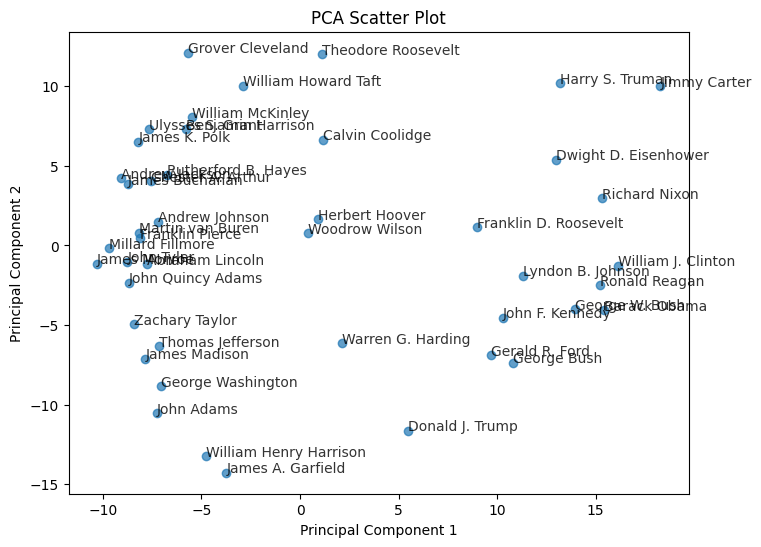

In [4]:
pca = PCA()
pca_result = pca.fit_transform(df)


# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)

# Annotate points with their labels
for i, txt in enumerate(df.index):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=10, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.show()

# Hierarchical Clustering

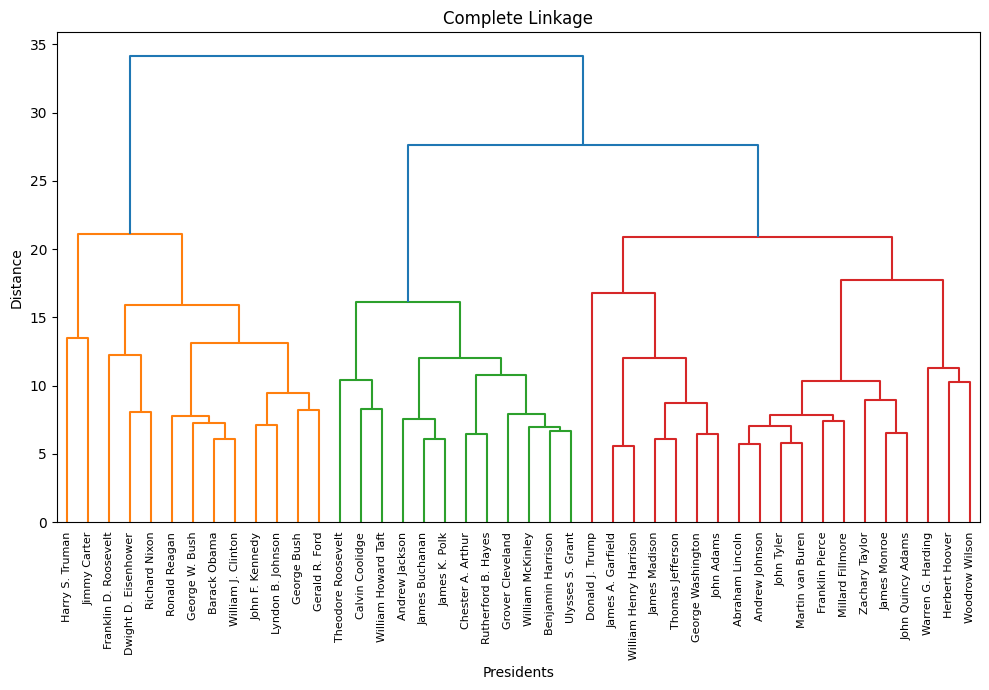

In [5]:
# Create distance matrix and perform complete linkage hierarchical clustering
linkage_matrix = linkage(df.to_numpy(), method='complete')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90) 
plt.title('Complete Linkage')
plt.xlabel('Presidents')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

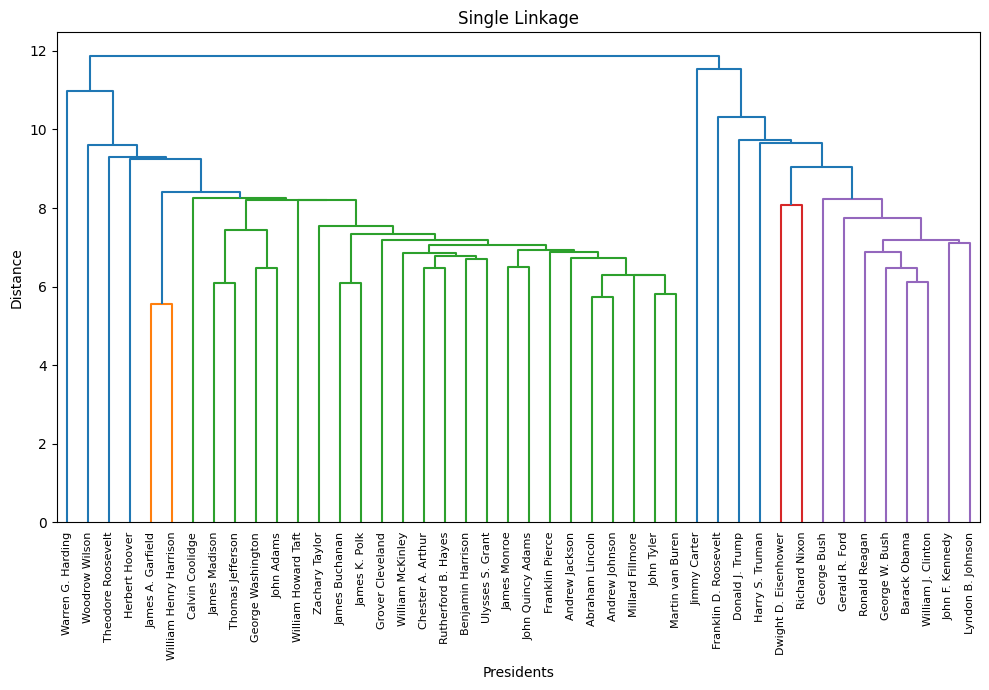

In [6]:
# Now do single linkage hierarchical clustering
linkage_matrix = linkage(df.to_numpy(), method='single')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90) 
plt.title('Single Linkage')
plt.xlabel('Presidents')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

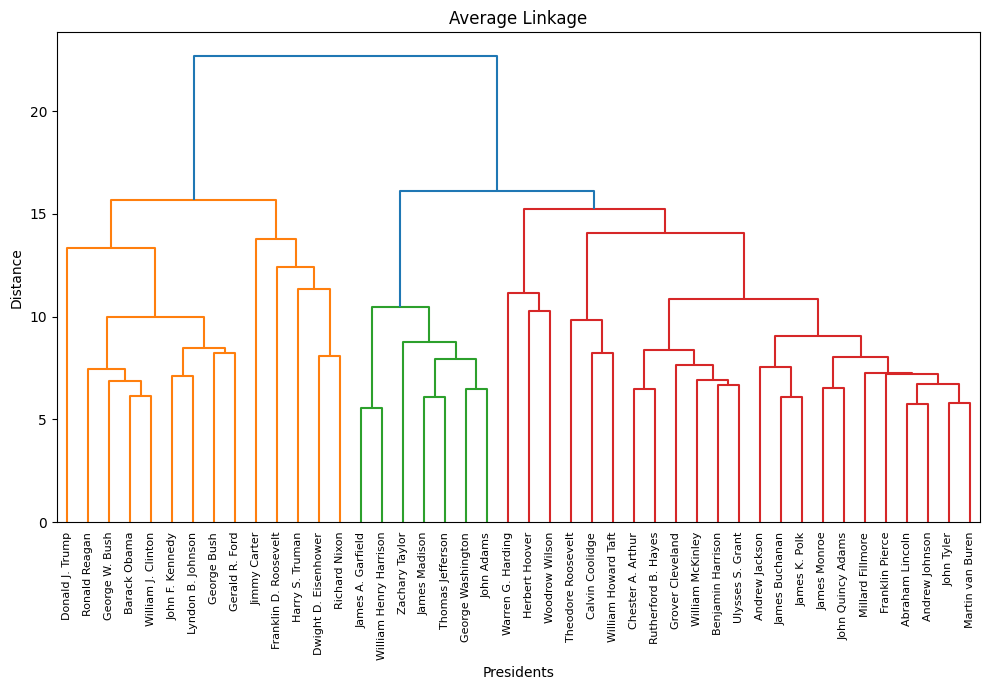

In [7]:
# Next do average linkage hierarchical clustering
linkage_matrix = linkage(df.to_numpy(), method='average')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90) 
plt.title('Average Linkage')
plt.xlabel('Presidents')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

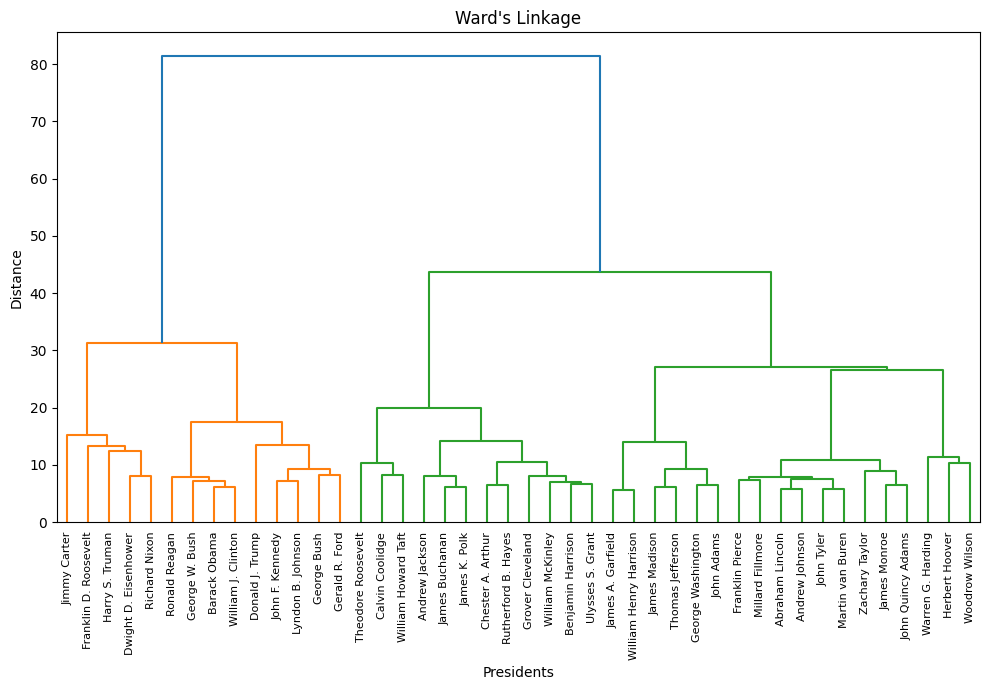

In [8]:
# Try Ward's linkage hierarchical clustering
linkage_matrix = linkage(df.to_numpy(), method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90) 
plt.title("Ward's Linkage")
plt.xlabel('Presidents')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

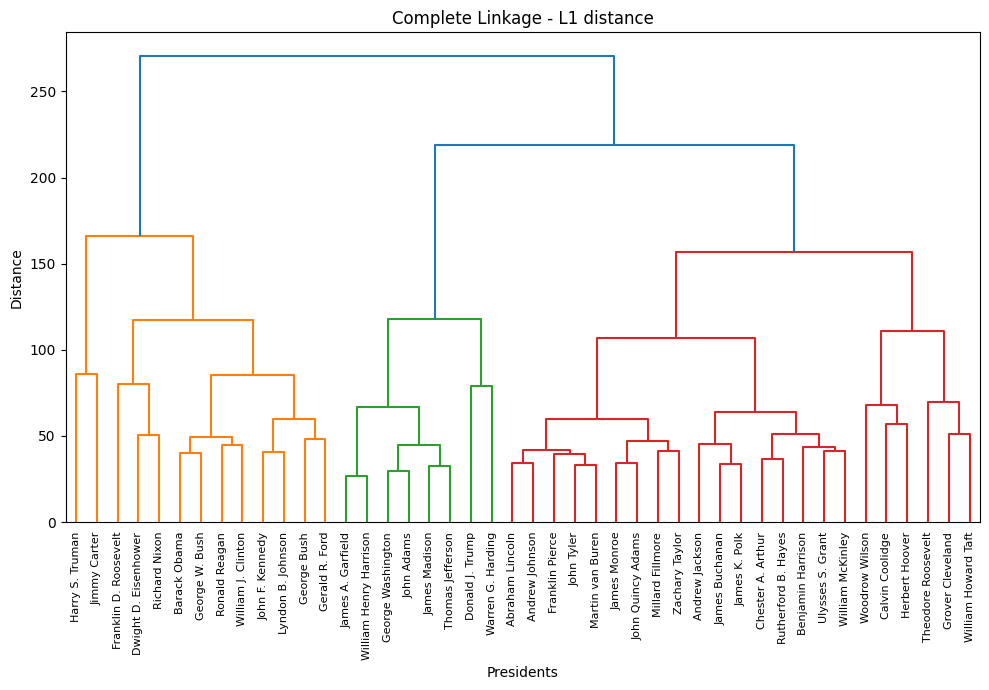

In [9]:
# Finally, let's do Complete Linkage again but this time use L1 distance
linkage_matrix = linkage(df.to_numpy(), method='complete', metric='cityblock')

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90) 
plt.title('Complete Linkage - L1 distance')
plt.xlabel('Presidents')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## Linakage Comparions on Simulated Data

In [10]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# Generate synthetic datasets
n_samples = 1000
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=170)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=170)
rng = np.random.RandomState(170)
no_structure = (rng.rand(n_samples, 2), None)

# Anisotropicly distributed data
X, y = datasets.make_blobs(n_samples=n_samples, random_state=170)
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# Blobs with varied variances
varied = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=170)


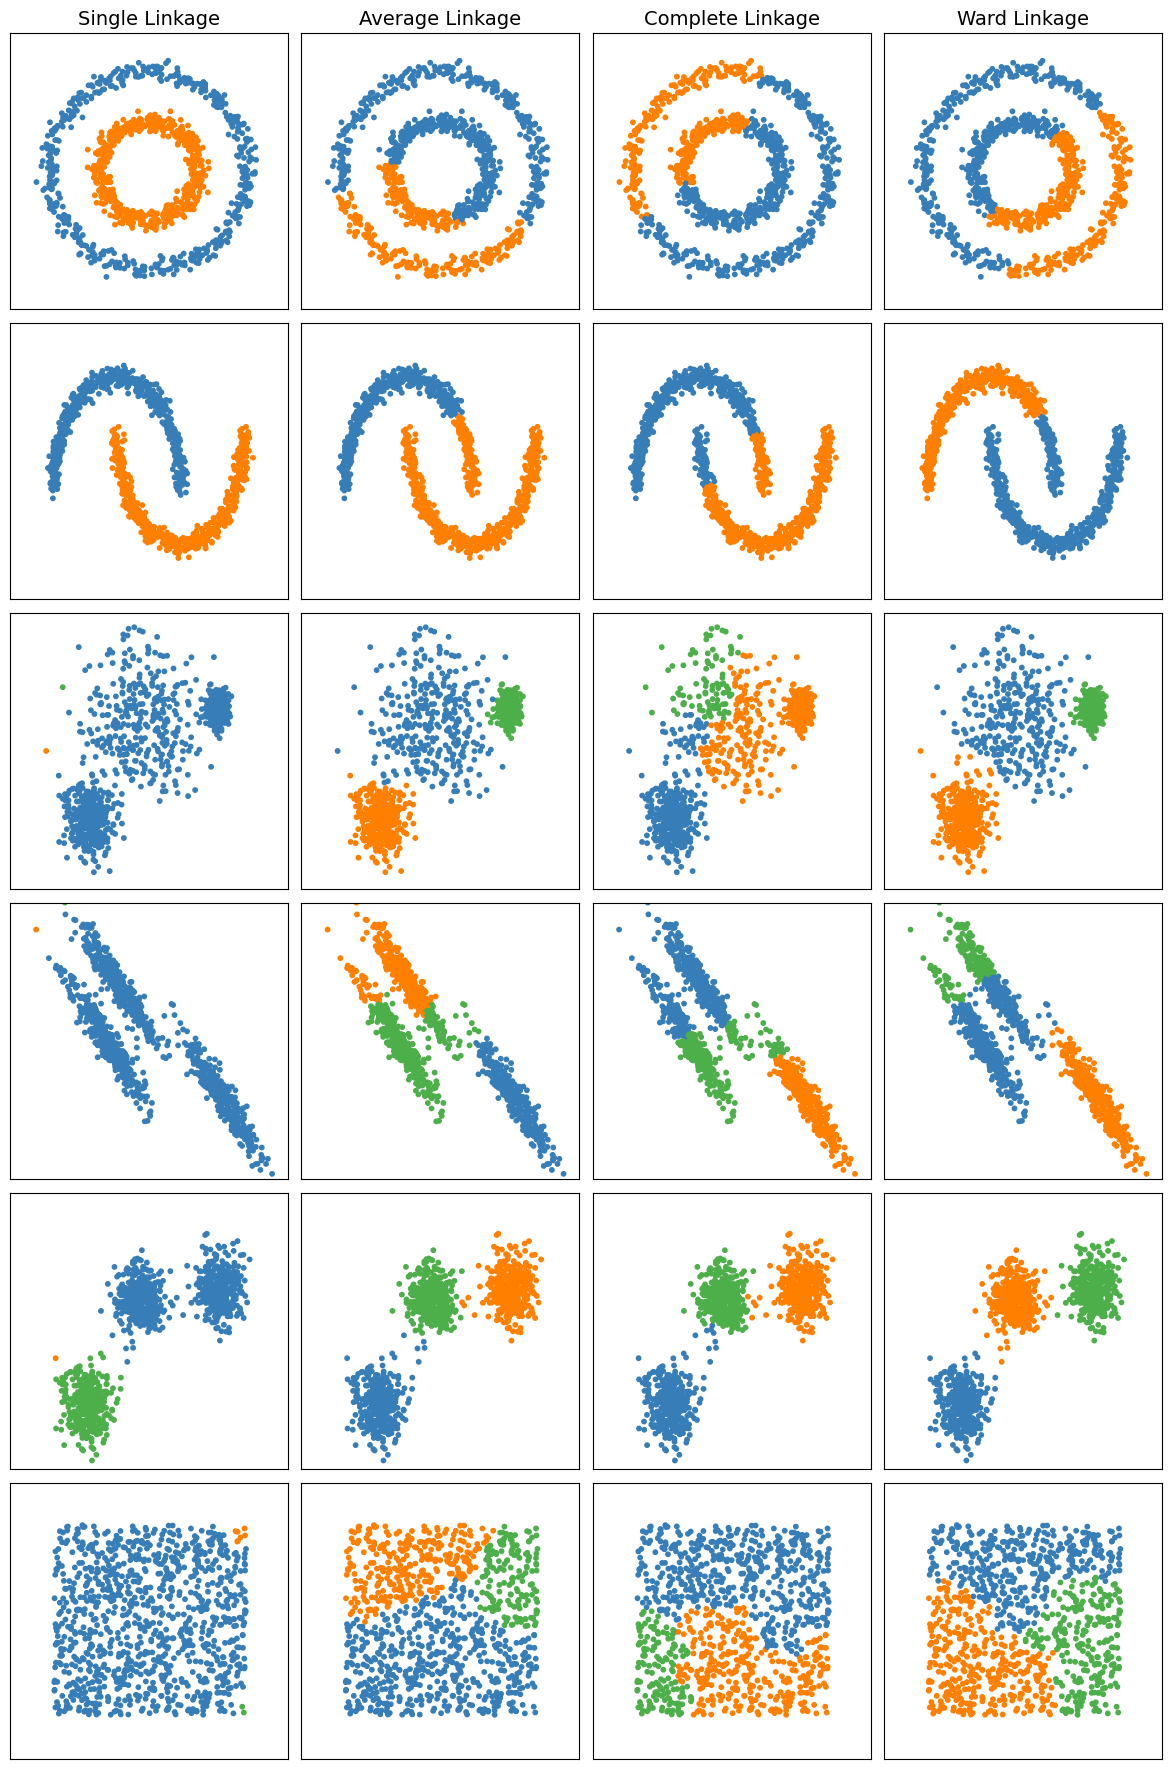

In [11]:
# Set up cluster parameters
plt.figure(figsize=(12, 18))
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.05)

plot_num = 1
default_base = {"n_neighbors": 10, "n_clusters": 3}

dataset_list = [
    (noisy_circles, {"n_clusters": 2}),
    (noisy_moons, {"n_clusters": 2}),
    (varied, {"n_neighbors": 2}),
    (aniso, {"n_neighbors": 2}),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(dataset_list):
    params = default_base.copy()
    params.update(algo_params)
    X, y = dataset

    # Normalize dataset
    X = StandardScaler().fit_transform(X)

    # Clustering Algorithms
    ward = cluster.AgglomerativeClustering(n_clusters=params.get("n_clusters", 3), linkage="ward")
    complete = cluster.AgglomerativeClustering(n_clusters=params.get("n_clusters", 3), linkage="complete")
    average = cluster.AgglomerativeClustering(n_clusters=params.get("n_clusters", 3), linkage="average")
    single = cluster.AgglomerativeClustering(n_clusters=params.get("n_clusters", 3), linkage="single")

    clustering_algorithms = [
        ("Single Linkage", single),
        ("Average Linkage", average),
        ("Complete Linkage", complete),
        ("Ward Linkage", ward),
    ]

    for name, algorithm in clustering_algorithms:
        y_pred = algorithm.fit_predict(X)  # Fit and predict

        plt.subplot(len(dataset_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=14)

        colors = np.array(
            list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"]),
                        int(max(y_pred) + 1)))
        )
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plot_num += 1

plt.show()


# Clustering Validation

## Silhouette Scores

Best K: 2 with silhouette score: 0.4113


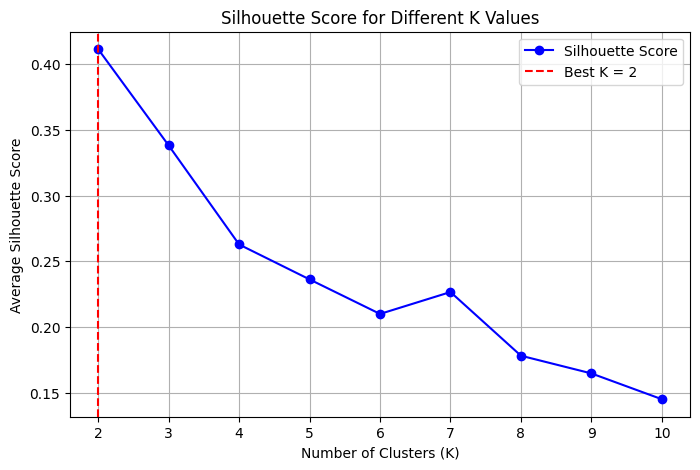

In [12]:
#validation for K-means clustering - how to choose K

#Silhouette Scores
ave_silhouette = {}

K = 10
for i in range(2,K+1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(df.to_numpy())
    silhouette_vals = silhouette_samples(df.to_numpy(), cluster_labels)
    ave_silhouette[i] = np.mean(silhouette_vals)

    
best_k = max(ave_silhouette, key=ave_silhouette.get)
print(f"Best K: {best_k} with silhouette score: {ave_silhouette[best_k]:.4f}")
    
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(ave_silhouette.keys()), list(ave_silhouette.values()), marker='o', linestyle='-', color='b', label="Silhouette Score")
plt.axvline(best_k, color='r', linestyle="--", label=f"Best K = {best_k}")  # Highlight best K
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.legend()
plt.grid(True)
plt.show()


Abraham Lincoln: 0.532
Andrew Jackson: 0.510
Andrew Johnson: 0.514
Barack Obama: 0.514
Benjamin Harrison: 0.455
Calvin Coolidge: 0.183
Chester A. Arthur: 0.514
Donald J. Trump: 0.154
Dwight D. Eisenhower: 0.412
Franklin D. Roosevelt: 0.314
Franklin Pierce: 0.520
George Bush: 0.437
George W. Bush: 0.507
George Washington: 0.401
Gerald R. Ford: 0.373
Grover Cleveland: 0.389
Harry S. Truman: 0.305
Herbert Hoover: 0.163
James A. Garfield: 0.222
James Buchanan: 0.518
James K. Polk: 0.493
James Madison: 0.443
James Monroe: 0.522
Jimmy Carter: 0.393
John Adams: 0.374
John F. Kennedy: 0.430
John Quincy Adams: 0.509
John Tyler: 0.536
Lyndon B. Johnson: 0.481
Martin van Buren: 0.523
Millard Fillmore: 0.543
Richard Nixon: 0.498
Ronald Reagan: 0.554
Rutherford B. Hayes: 0.486
Theodore Roosevelt: 0.161
Thomas Jefferson: 0.432
Ulysses S. Grant: 0.489
Warren G. Harding: 0.034
William Henry Harrison: 0.268
William Howard Taft: 0.341
William J. Clinton: 0.531
William McKinley: 0.437
Woodrow Wilson: 0.2

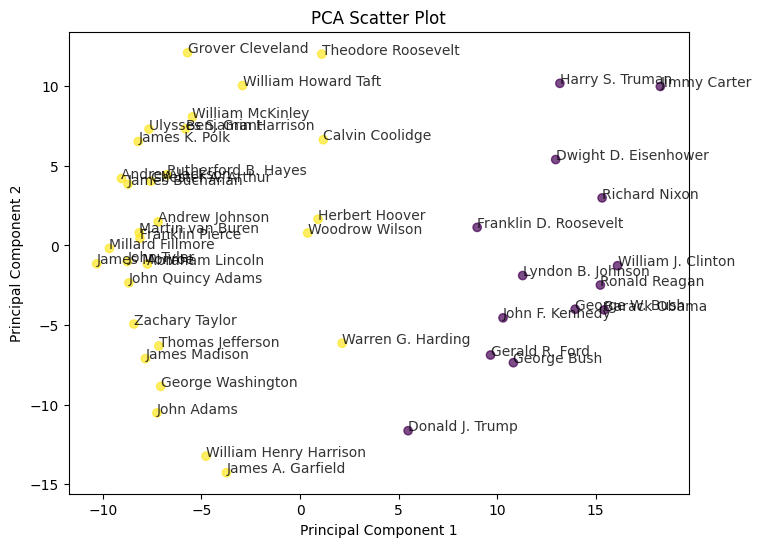

In [13]:
#visualize K=2 clusters and print silhoutte scores

K = 2
kmeans = KMeans(n_clusters=K, random_state=42)
cluster_labels = kmeans.fit_predict(df.to_numpy())
silhouette_vals = silhouette_samples(df.to_numpy(), cluster_labels)

# Print silhouette scores
for i, label in enumerate(df.index):  
    print(f'{label}: {silhouette_vals[i]:.3f}')
    

# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, alpha=0.7)

# Annotate points with their labels
for i, txt in enumerate(df.index):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=10, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.show()



## Stability: Consensus Clustering

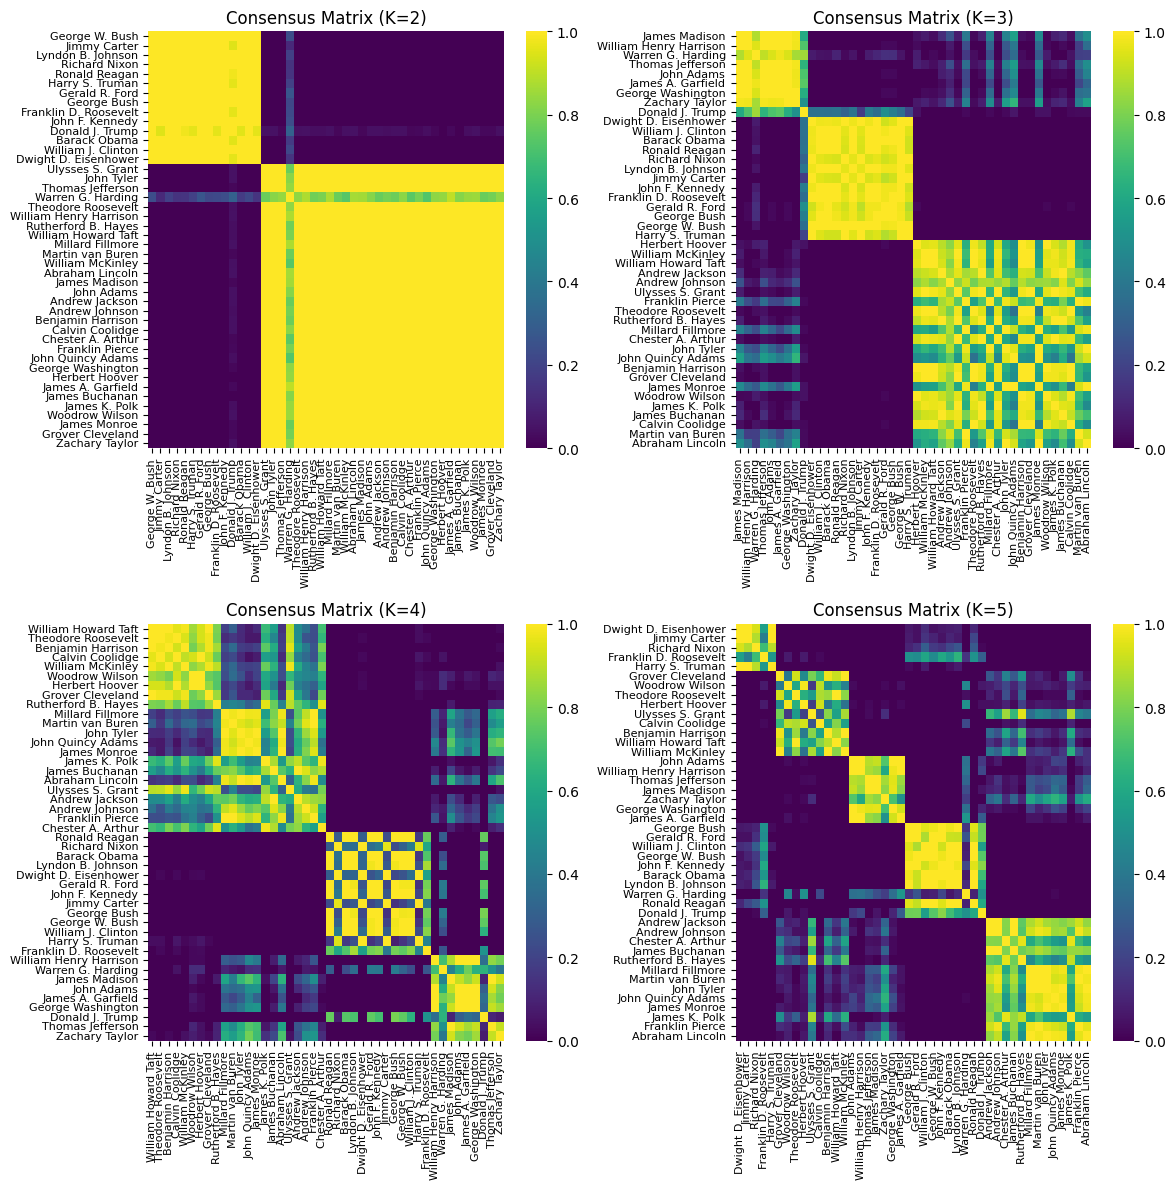

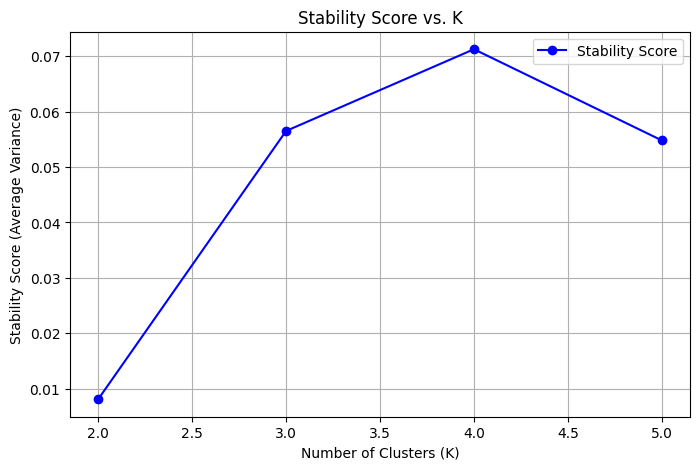

In [14]:
# Parameters
rng = np.random.default_rng(42)
iterations = 100
K_values = [2, 3, 4, 5]  # Different K values
stability_scores = []  # Store stability scores for each K

fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2x2 grid for consensus matrices
axes = axes.flatten()  # Flatten for easy iteration

for idx, K in enumerate(K_values):
    n_samples = df.shape[0]
    consensus_matrix = np.zeros((n_samples, n_samples))
    sampled_matrix = np.zeros((n_samples, n_samples))

    sample_names = df.index.to_numpy()

    # Bootstrap clustering
    for n in range(iterations):
        train_idx = rng.choice(n_samples, size=int(0.7 * n_samples), replace=False)
        X_train = df.iloc[train_idx].to_numpy()

        # Run k-means on the training data
        km = KMeans(n_clusters=K, random_state=n, n_init=10)
        cluster_labels = km.fit_predict(X_train)

        # Update sampled matrix
        sampled_matrix[np.ix_(train_idx, train_idx)] += 1

        # Create co-membership matrix for this iteration
        co_members = np.equal.outer(cluster_labels, cluster_labels)

        # Update consensus matrix for sampled indices
        consensus_matrix[np.ix_(train_idx, train_idx)] += co_members

    # Normalize consensus matrix
    with np.errstate(divide='ignore', invalid='ignore'):
        consensus_matrix = np.divide(consensus_matrix, sampled_matrix, where=(sampled_matrix != 0))
        consensus_matrix = np.nan_to_num(consensus_matrix)  # Replace NaN with 0

    # Final KMeans clustering on full dataset
    final_km = KMeans(n_clusters=K, random_state=42, n_init=10)
    final_clusters = final_km.fit_predict(df.to_numpy())

    # Sort consensus matrix for visualization
    order_idx = np.argsort(final_clusters)
    consensus_matrix = consensus_matrix[order_idx][:, order_idx]

    # Plot consensus matrix
    sns.heatmap(consensus_matrix, ax=axes[idx], cmap='viridis', xticklabels=sample_names[order_idx],yticklabels=sample_names[order_idx],)
    axes[idx].set_title(f'Consensus Matrix (K={K})')
    axes[idx].tick_params(axis='x', rotation=90, labelsize=8)  
    axes[idx].tick_params(axis='y', labelsize=8)  

    # Compute stability score (variance of off-diagonal consensus scores)
    stability_score = 0
    n_pairs = 0

    for i in range(n_samples):
        for j in range(i + 1, n_samples):  # Only consider off-diagonal elements
            stability_score += consensus_matrix[i, j] * (1 - consensus_matrix[i, j])
            n_pairs += 1

    stability_score /= n_pairs  # Normalize by number of pairs
    stability_scores.append(stability_score)

plt.tight_layout()
plt.show()

# Plot stability scores
plt.figure(figsize=(8, 5))
plt.plot(K_values, stability_scores, marker='o', linestyle='-', color='b', label="Stability Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Stability Score (Average Variance)")
plt.title("Stability Score vs. K")
plt.legend()
plt.grid()
plt.show()

---

# Clustering Validation with CARVE:

In [15]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))

from carve import CARVE


N_JOBS = 10

### CARVE Algorithm

**Input:** Data $X$, clustering method $f(\cdot, \theta)$ with $k$ clusters, $B$ resampling iterations, subsampling proportion $\rho$

**Output:** 
- Stability scores $\{S_b\}_k$, generalizability scores $\{G_b\}_k$, 
- Consensus matrix $\widehat{M}_k \in \mathbb{R^{n \times n}}$, misclassification rates $\widehat{E}_k \in \mathbb{R^{n}}$, 

**For** $b = 1, \ldots, B$:

1. **Sub-sample.** Draw two subsamples $P_1^{(b)}, P_2^{(b)}$ and set $P_{\text{test}}^{(b)} = X \setminus P_1^{(b)}$
2. **Cluster.** Obtain clusterings $C_1^{(b)}, C_2^{(b)}, C_{\text{test}}^{(b)}$ using $f(\cdot, \theta)$
3. **Stability:**
   - *Global:* $S^{(b)}$ = ARI between $C_1^{(b)}$ and $C_2^{(b)}$ on their overlap
   - *Per-sample:* update consensus matrix with co-clustering from $C_1^{(b)}, C_2^{(b)}$
4. **Generalizability:** fit classifier $\hat{h}$ on $(P_1^{(b)}, C_1^{(b)})$, predict $\hat{C}_{\text{test}}^{(b)}$
   - *Global:* $G^{(b)}$ = ARI of $\hat{C}_{\text{test}}^{(b)}$ vs $C_{\text{test}}^{(b)}$
   - *Per-sample:* update per-sample accuracy from $C_{\text{test}}^{(b)}, \hat{C}_{\text{test}}^{(b)}$

**Aggregate.** Report means, standard errors, and 95% quantiles of $\{S_b\}$ and $\{G_b\}$. Report consensus matrix and per-sample misclassification rates.

Repeat for all $k \in \{1, 2, \dots, K\}$ and clustering method/hyperparameter combinations $f(\cdot, \theta)$.

In [16]:
k_min = 2
K = 8

carve = CARVE(
    n_clusters=list(range(k_min, K+1)), 
    estimator_param_grids='light', 
    subsample_ratio=0.6, 
    
    n_jobs=N_JOBS, random_state=42
)

carve.fit(df, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 44
[CARVE] n_features         : 75
[CARVE] n_clusters         : [2 3 4 5 6 7 8]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 21
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/21] est=KMeans n_clusters=2 | ARI_stab=0.782±0.030  ARI_gen=0.692±0.032  
[CARVE] [2/21] est=KMeans n_clusters=3 | ARI_stab=0.603±0.025  ARI_gen=0.492±0.018  
[CARVE] [3/21] est=KMeans n_clusters=4 | ARI_stab=0.556±0.020  ARI_gen=0.431±0.016  
[CARVE] [4/21] est=KMeans n_clusters=5 | ARI_stab=0.544±0.019  ARI_gen=0.439±0.016  
[CARVE] [5/21] est=KMeans n_clusters=6 | ARI_stab=0.521±0.018  ARI_gen=0.430±0.016  
[CARVE] [6/21] est=KMeans n_clusters=7 | ARI_stab=0.536±0.017  ARI_g

,n_clusters,"[2, 3, ...]"
,n_resamples,100
,subsample_ratio,0.6
,estimator_param_grids,'light'
,normalization_options,None
,dim_reduction_options,None
,reference_labels,None
,n_jobs,10
,random_state,42
,verbose,1


We will first consider CARVE's stability-based measures:

<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Stability'>

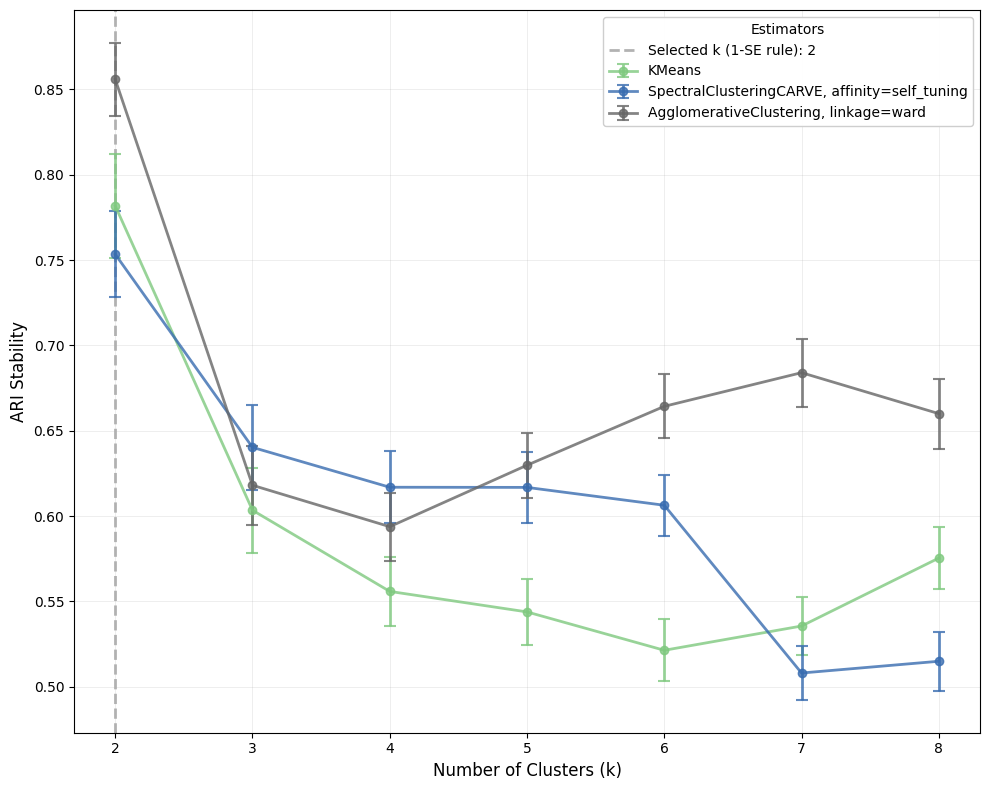

In [17]:
measure = 'stability'

carve.plot_metric_over_n_clusters(measure=measure, figsize=(10, 8))

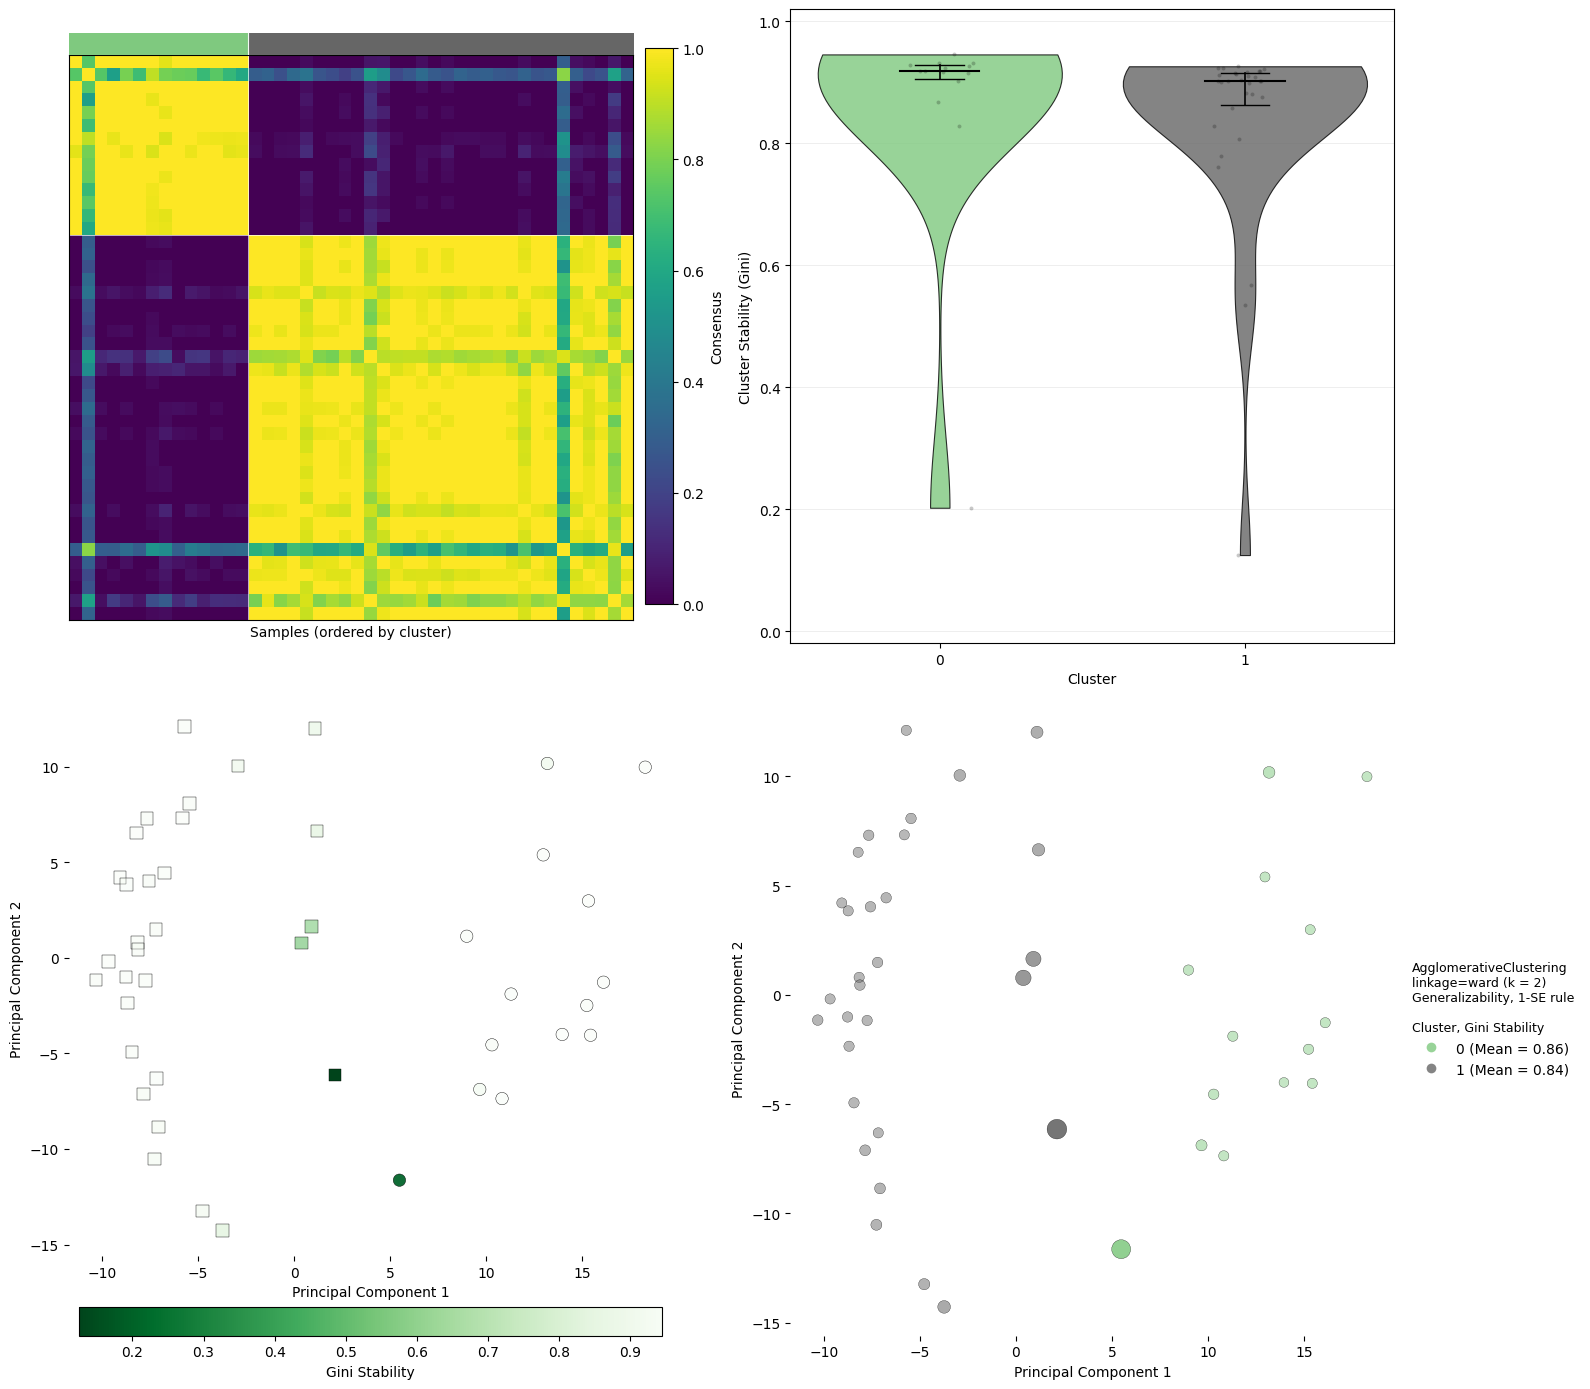

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

carve.plot_consensus_matrix(measure=measure, ax=axes[0, 0])
carve.plot_cluster_violin(measure=measure, ax=axes[0, 1], annotation=False)
carve.plot_diagnostic_scatter(
    measure=measure, 
    xlabel='Principal Component 1', ylabel='Principal Component 2',
    ax=axes[1, 0], legend=False, 
    marker_size=80
)
carve.plot_cluster_scatter(
    measure=measure, 
    size_range=(50, 200), xlabel='Principal Component 1', ylabel='Principal Component 2', 
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

And we now consider CARVE's generalizability-based metrics:


Often clusterings evaluated according to stability & generalizability will have high values for $k=2$. However, these are not always the most informative and scientifically interesting clusters. 
Setting $\texttt{not\_two = True}$ excludes clustering solutions with $k=2$ from the selection of $k$. 

<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Generalizability'>

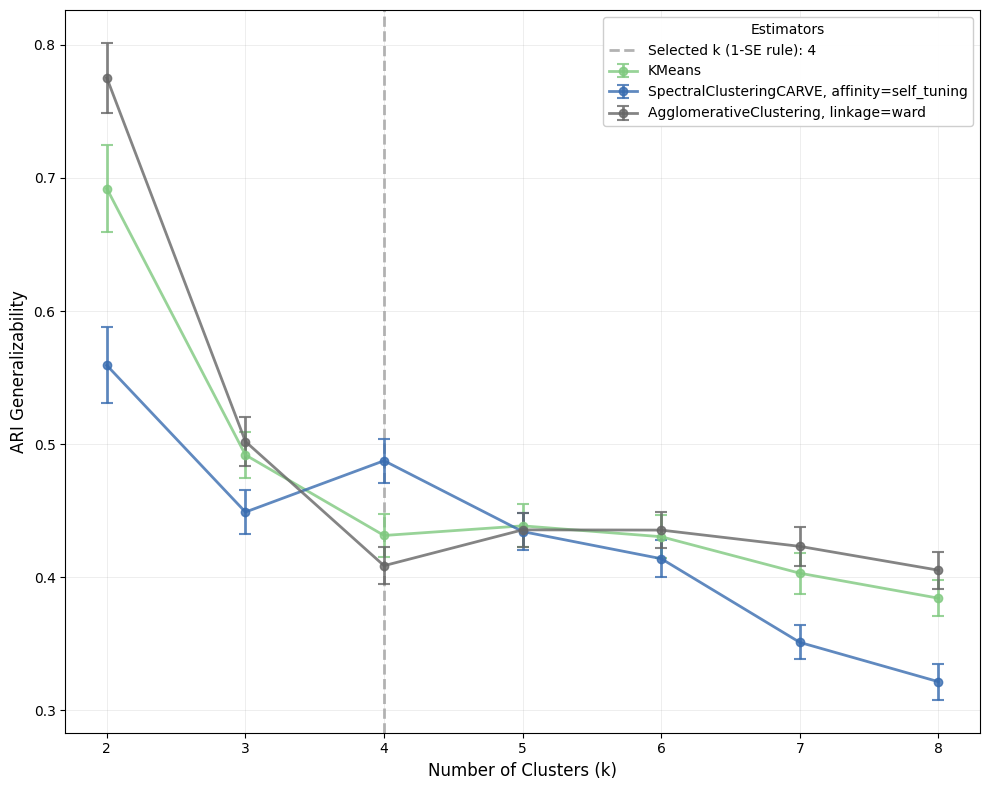

In [19]:
measure = 'generalizability'

carve.plot_metric_over_n_clusters(measure=measure, not_two=True, figsize=(10, 8))

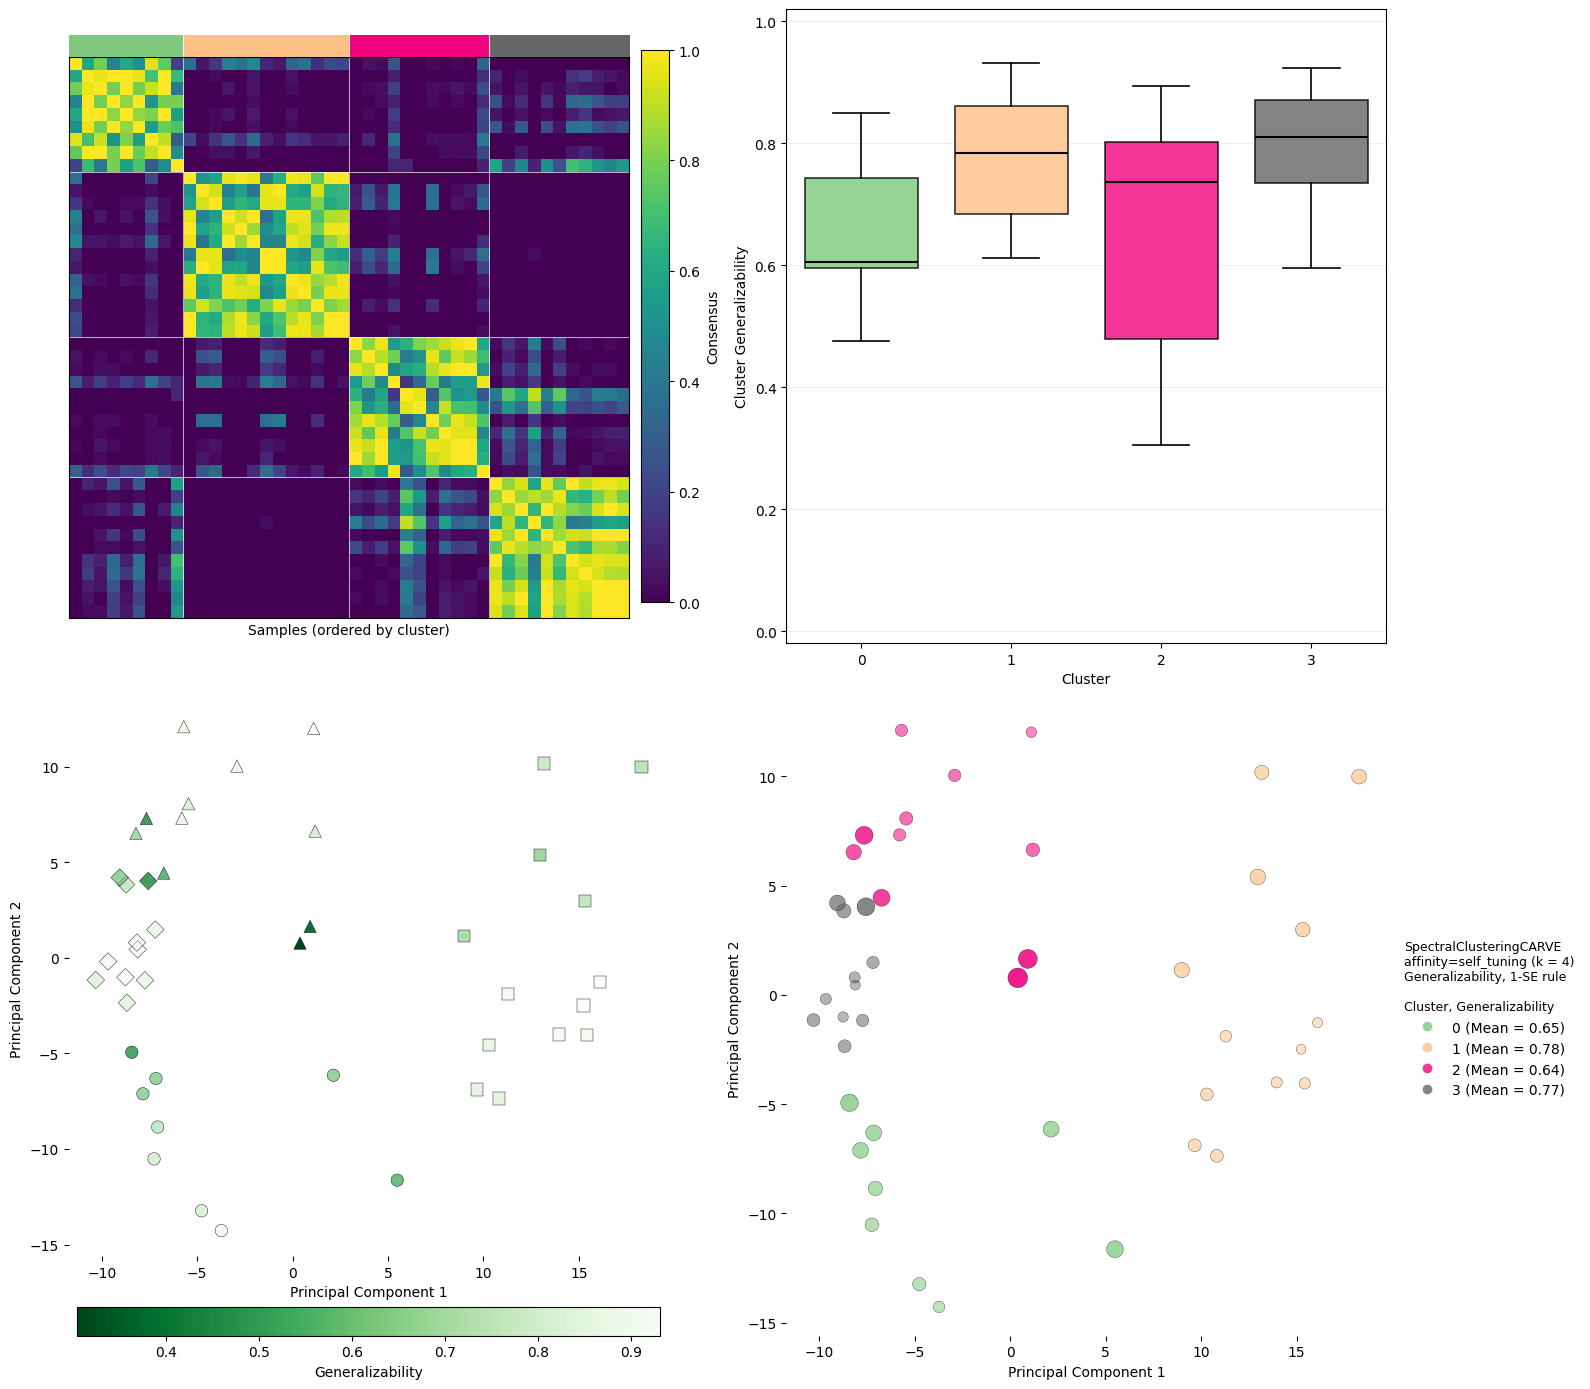

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

carve.plot_consensus_matrix(measure=measure, not_two=True, ax=axes[0, 0])
carve.plot_cluster_boxplot(measure=measure, source='accuracy', not_two=True, ax=axes[0, 1], annotation=False)
carve.plot_diagnostic_scatter(
    measure=measure, not_two=True, 
    source='accuracy', 
    xlabel='Principal Component 1', ylabel='Principal Component 2',
    ax=axes[1, 0], legend=False,
    marker_size=80
)
carve.plot_cluster_scatter(
    measure=measure, not_two=True, 
    source='accuracy', 
    size_range=(50, 200), xlabel='Principal Component 1', ylabel='Principal Component 2',
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

Clustering according to generalizability:

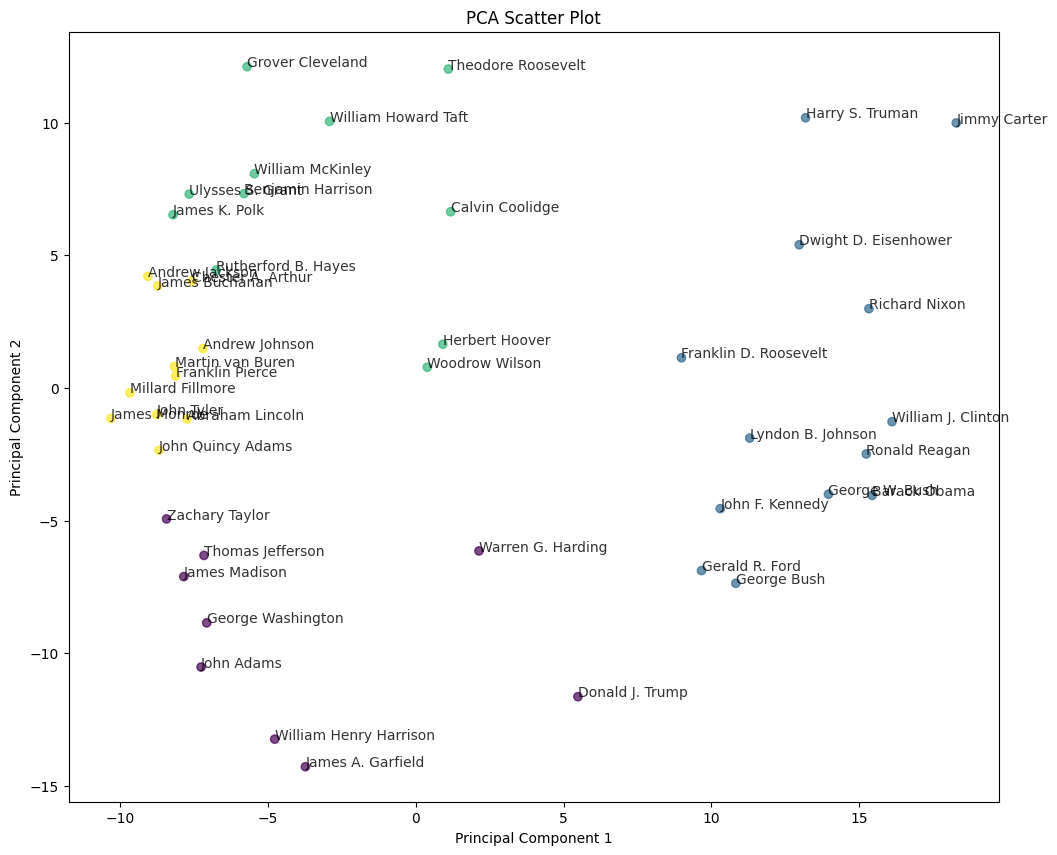

In [21]:
cluster_labels = carve.get_labels(measure='generalizability', not_two=True)

# Plot PCA results
plt.figure(figsize=(12, 10))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, alpha=0.7)

# Annotate points with their labels
for i, txt in enumerate(df.index):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=10, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.show()

---